# Cryptic pocket analysis.

In [1]:
import  numpy as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")

mpl.rcParams['font.family'] = ['serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['font.size'] = 8.

systems = {'test0_ubq':   r"Ubiquitin", 
           'test1_adk':   r"AdK", 
           'test2_tem1':  r"TEM-1", 
           'test3_bclxl': r"Bcl-x$_L$", 
           'test4_blg':   r"βLG", 
           'test5_ndka':  r"NDPK-A", 
           'test6_gltp':  r"GLTP", }
cm = 1/2.54  # centimeters in inches
colors = ["#F9D9D8", "#EDA3B2", "#7E73AC"]

In [2]:
def get_loss_profile(which_system: str) -> dict[str, np.ndarray]:
  p = {'repelling': list(), 
       'anchoring': list(), 
       'rigidbody': list(), 
       'cistogram': list(), 
       'plddt':     list(), }
  with open(f"{which_system}/aftools_runtime/afre/afre_traj.log", 'r') as f:
    lines = [_ for _ in f.readlines() if '|' in _]
    for line in lines:
      words = line.split()
      for _ in range(len(words)):
        if words[_] in p:
          p[words[_]].append(float(words[_+1]))
  for k, v in p.items():
    assert len(v)==10000 or len(v)==20000, len(v)
  return p

15.0 19.0
15.0 19.0
15.0 19.0
15.0 19.0
15.0 19.0
15.0 19.0
15.0 19.0


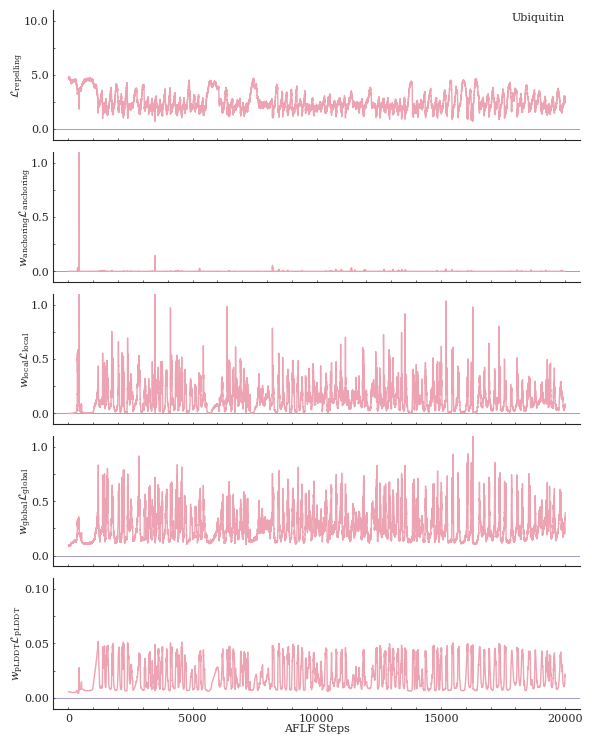

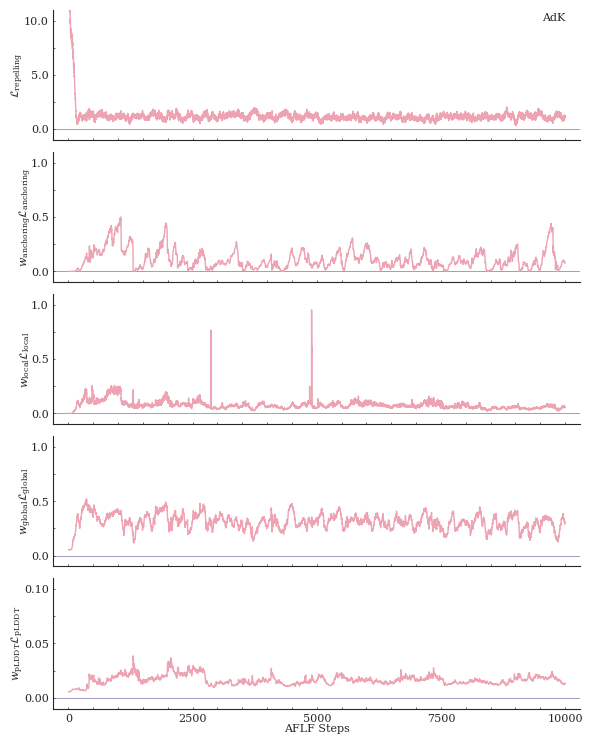

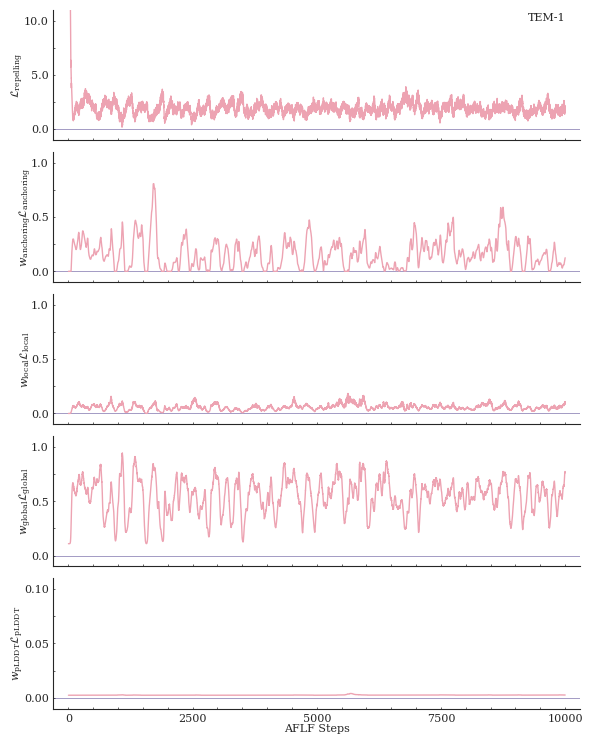

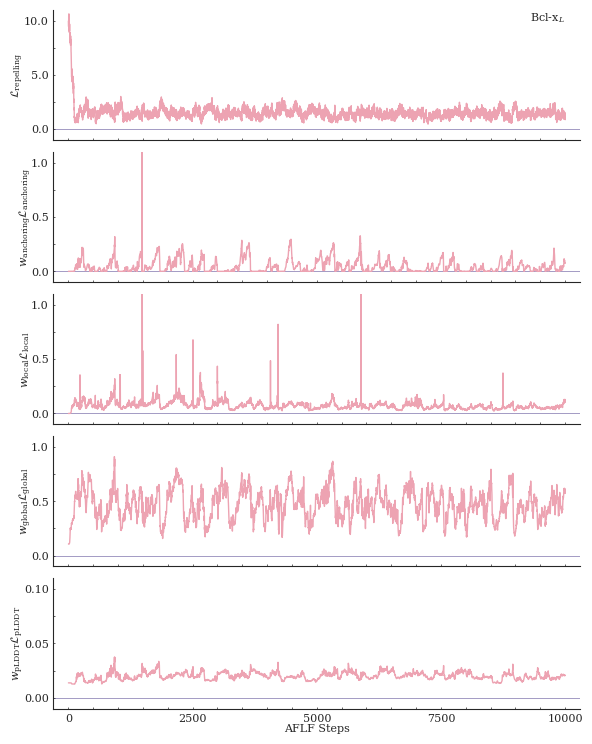

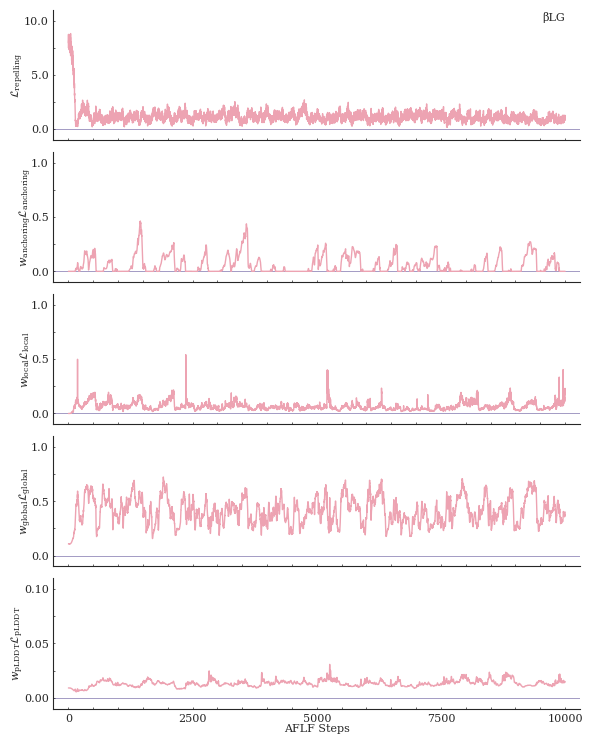

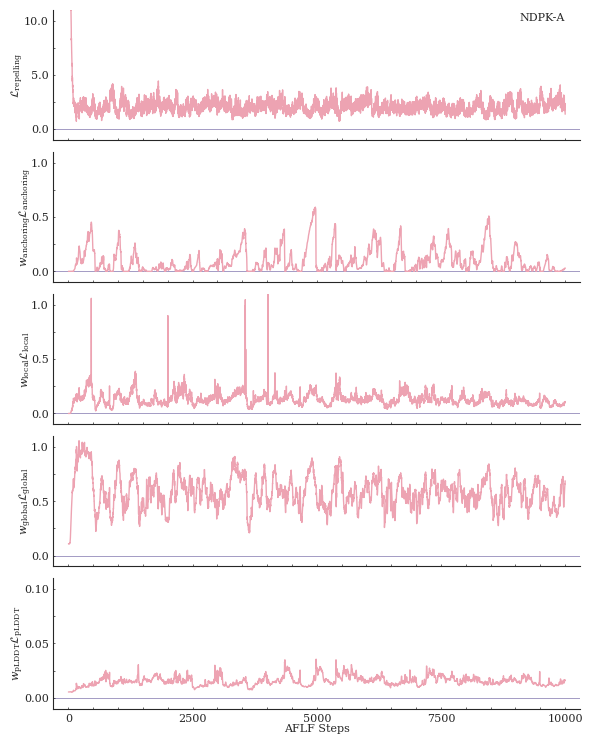

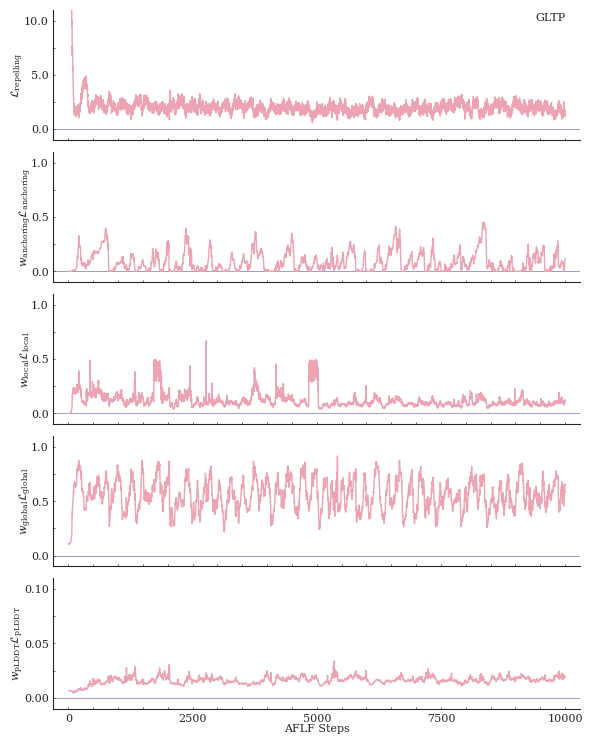

In [3]:
for system_name, protein_name in systems.items():
  profile = get_loss_profile(which_system=system_name)
  figspec= {'lmargin':11/8*cm, 
            'rmargin':1/4*cm,
            'hgap':    1/4*cm,
            'hsize':  107/8*cm,
            'bmargin': 1  *cm,
            'tmargin': 1/4*cm,
            'vgap':    1/4*cm,
            'vsize':   11/4*cm, }

  figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
             figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*5 + figspec['tmargin'], )
  print(figsize[0]/cm, figsize[1]/cm)

  fig, axes = plt.subplots(5, 1, figsize=figsize, sharex=True, 
      gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                       bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                       wspace=figspec['hgap']/figspec['hsize'],
                       hspace=figspec['vgap']/figspec['vsize'], ))

  for _, (pk, pv) in enumerate(profile.items()):
    axes[_].plot(np.arange(1, len(pv)+1), pv, ls='-', lw=1., c=colors[1])
    axes[_].axhline(y=0., color=colors[2], ls='-', lw=0.5, zorder=0)
    axes[_].set(xlim=(-300, 10300) if not system_name=='test0_ubq' else (-600, 20600), 
                xticks=(   0,  500, 1000, 1500, 2000, 
                        2500, 3000, 3500, 4000, 4500, 
                        5000, 5500, 6000, 6500, 7000, 
                        7500, 8000, 8500, 9000, 9500, 10000
                        ) if not system_name=='test0_ubq' else (
                            0,  1000,  2000,  3000,  4000, 
                         5000,  6000,  7000,  8000,  9000, 
                        10000, 11000, 12000, 13000, 14000, 
                        15000, 16000, 17000, 18000, 19000, 20000), 
                xticklabels=(    0, '', '', '', '', 
                              2500, '', '', '', '', 
                              5000, '', '', '', '', 
                              7500, '', '', '', '', 10000
                             ) if not system_name=='test0_ubq' else (
                                 0, '', '', '', '', 
                              5000, '', '', '', '', 
                             10000, '', '', '', '', 
                             15000, '', '', '', '', 20000), )
    axes[_].minorticks_off()
    axes[_].spines[['top','right']].set_visible(False)
    axes[_].tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
  axes[0].text(10000 if not system_name=='test0_ubq' else 20000, 10., protein_name, ha='right')
  axes[0].set(ylim=(-1, 11), 
              yticks=(0., 2.5, 5.0, 7.5, 10.0),
              yticklabels=('0.0', '', '5.0', '', '10.0'), )
  axes[0].set_ylabel(r'$\mathcal{L}_{\text{repelling}}$', fontsize=8, va='center')
  axes[1].set(ylim=(-0.1, 1.1), 
              yticks=(0., .25, 0.50, .75, 1.00),
              yticklabels=('0.0', '', '0.5', '', '1.0'), )
  axes[1].set_ylabel(r'$w_{\text{anchoring}}\mathcal{L}_{\text{anchoring}}$', fontsize=8, va='center')
  axes[2].set(ylim=(-0.1, 1.1), 
              yticks=(0., .25, 0.50, .75, 1.00),
              yticklabels=('0.0', '', '0.5', '', '1.0'), )
  axes[2].set_ylabel(r'$w_{\text{local}}\mathcal{L}_{\text{local}}$', fontsize=8, va='center')
  axes[3].set(ylim=(-0.1, 1.1), 
              yticks=(0., .25, 0.50, .75, 1.00),
              yticklabels=('0.0', '', '0.5', '', '1.0'), )
  axes[3].set_ylabel(r'$w_{\text{global}}\mathcal{L}_{\text{global}}$', fontsize=8, va='center')
  axes[4].set(ylim=(-0.01, 0.11), 
              yticks=(0., .025, 0.050, .075, .100),
              yticklabels=('0.00', '', '0.05', '', '0.10'), )
  axes[4].set_ylabel(r'$w_{\text{pLDDT}}\mathcal{L}_{\text{pLDDT}}$', fontsize=8, va='center')
  axes[-1].set_xlabel(r'AFLF Steps', fontsize=8, va='center')
  plt.savefig(f"./zfigures/fig_loss_profile_{system_name.split('_')[1]}.jpg", dpi=300)